# Compare deconvolution with and without copy number correction

Levels to think about:
- 10kb
- Per gene
- Per gene promoter

Ideas:
- Copy number correction may affect nucleosome occupancy and promoter occupancy during S-phase, thus we'll have to think about the low hanging fruit to show how copy number correction improves the fit of the chromatin deconvolution.
- At a high-level it should be most clear at the 10kb window.
- Then on the gene-level. The gene level is a bit more challenging because of the different regulation dynamics at play, but it allows us to investigate dosage compensation-type ideas.



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [156]:
from pipeline.copy_correction_analysis import CopyCorrectionAnalysis

output_dir = 'output/prototype_pipeline_subset/'
copy_correction_analysis = CopyCorrectionAnalysis(output_dir)


In [3]:
copy_correction_analysis.load_chromosome(chrom=4)

In [352]:
copy_correction_analysis.load_means_all_chromosomes()

Chromosome 1...00:00:00.779
Chromosome 2...00:00:05.105
Chromosome 3...00:00:06.088
Chromosome 4...00:00:16.701
Chromosome 5...00:00:18.600
Chromosome 6...00:00:19.440
Chromosome 7...00:00:26.532
Chromosome 8...00:00:28.428
Chromosome 9...00:00:29.812
Chromosome 10...00:00:33.213
Chromosome 11...00:00:36.515
Chromosome 12...Skipping index 47
00:00:43.147
Chromosome 13...00:00:47.743
Chromosome 14...00:00:50.798
Chromosome 15...Skipping index 108
00:00:56.579
Chromosome 16...00:01:00.679


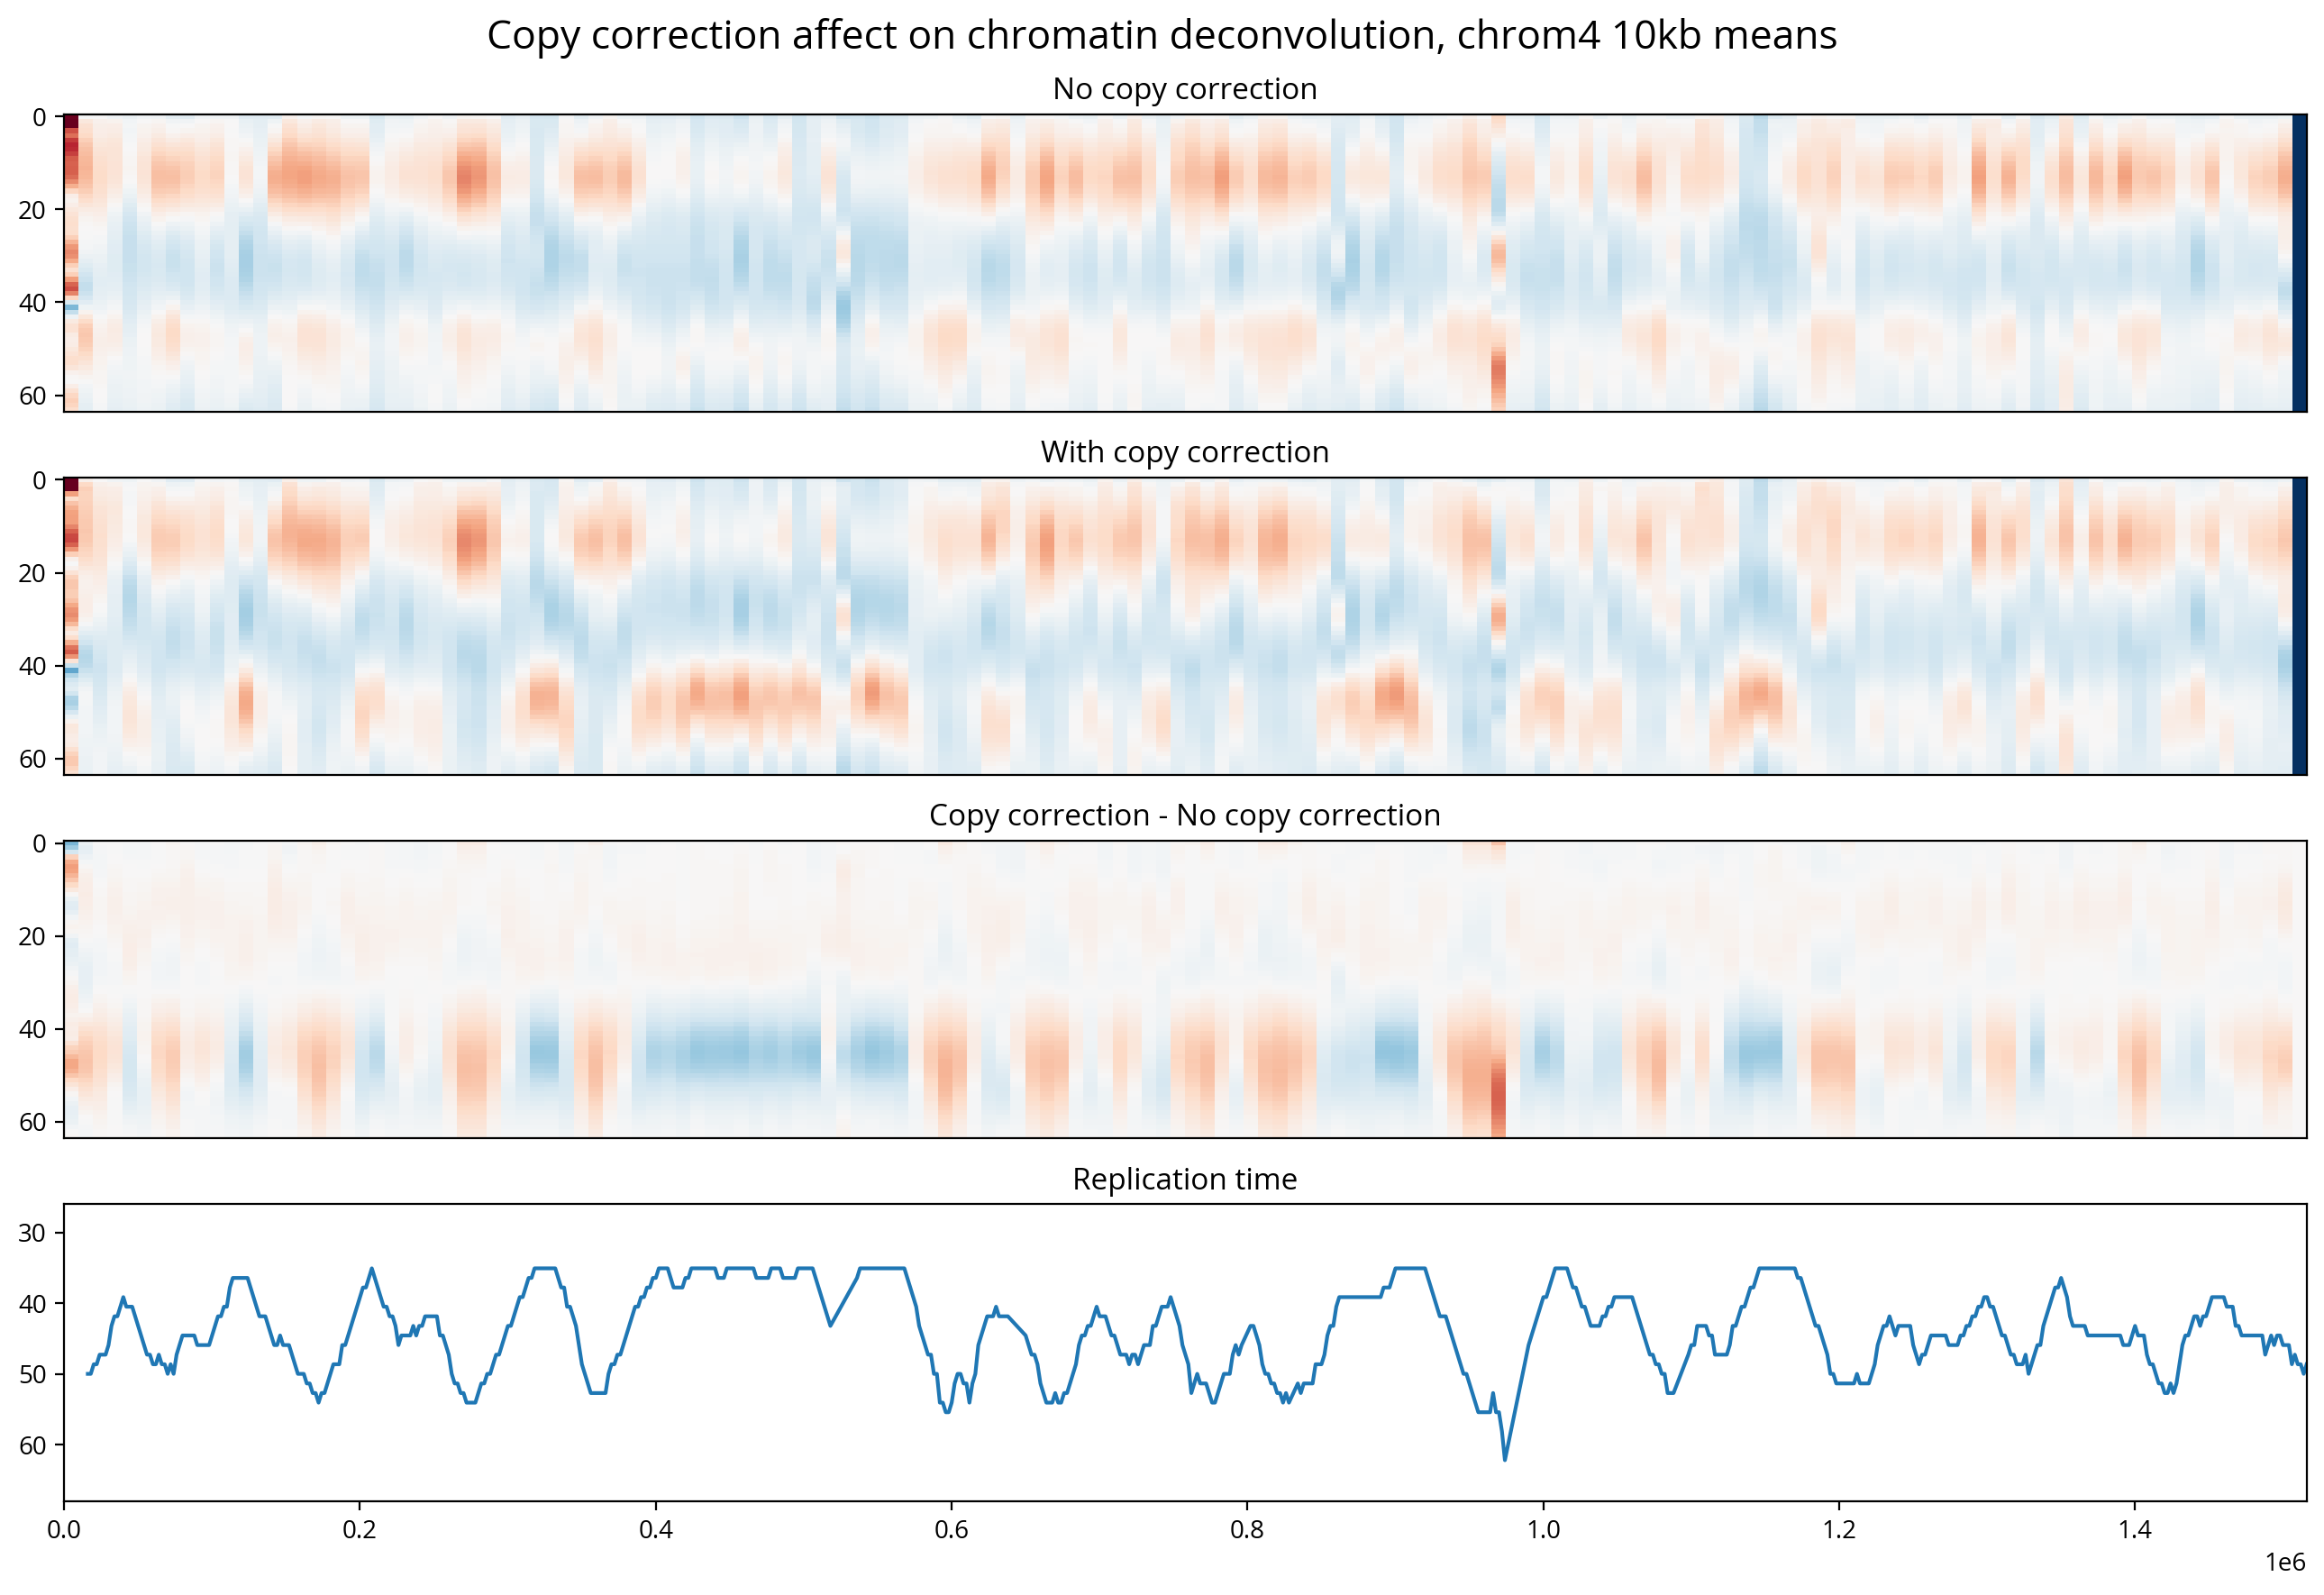

In [546]:
copy_correction_analysis.plot_heatmap_comparison(4)

In [355]:
copy_correction_analysis.compute_ptrs()

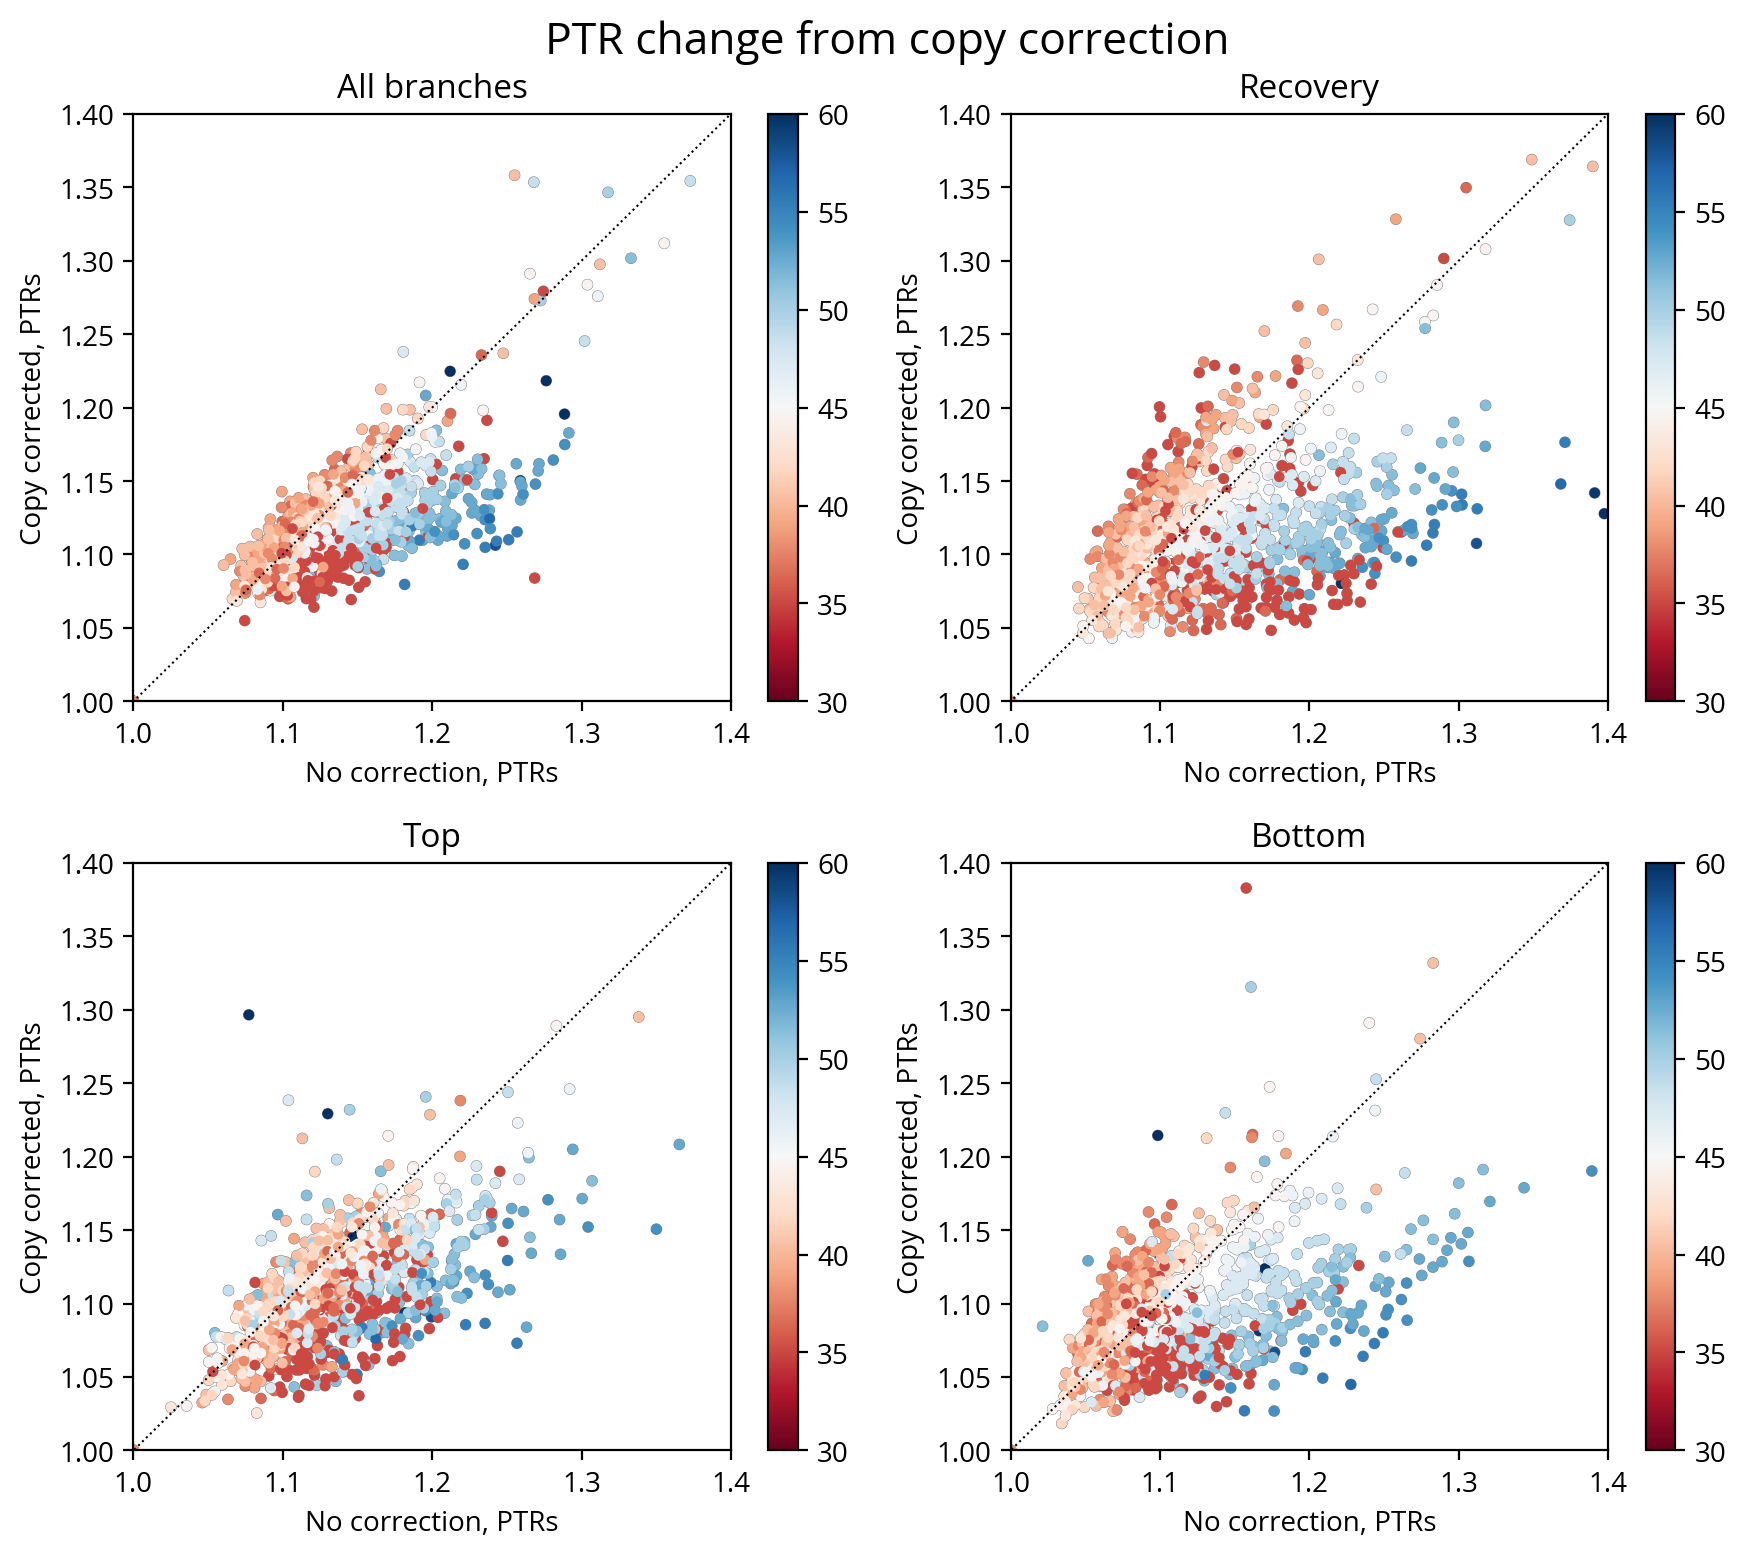

In [416]:
copy_correction_analysis.plot_branch_ptrs()

In [544]:
copy_correction_analysis.initialize_replication_time_colormaps()

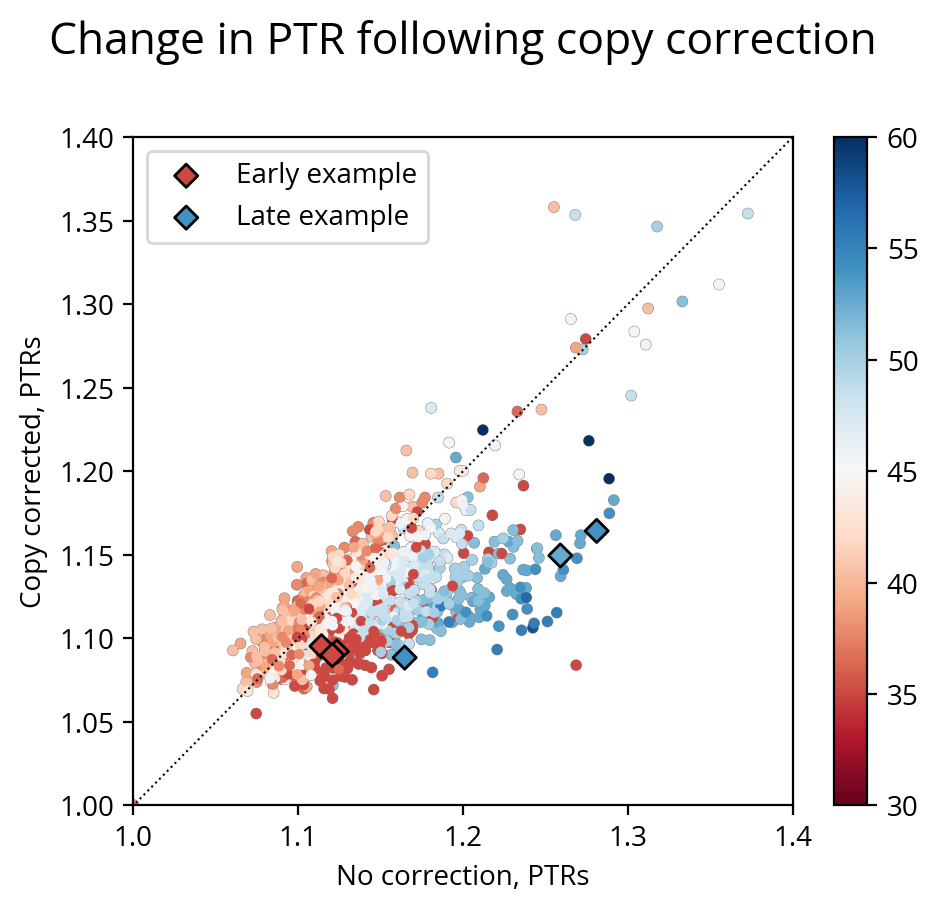

In [545]:

key_1 = 'no_cc_ptr_all'
key_2 = 'cc_ptr_all'

plt.figure(figsize=(5, 4.7))
copy_correction_analysis.plot_ptrs(key_1, key_2)
plt.title("Change in PTR following copy correction", fontsize=16, y=1.1)
plt.tight_layout()

late_window_repl_times = copy_correction_analysis.all_replication_times.loc[\
    copy_correction_analysis.late_windows]
early_window_repl_times = copy_correction_analysis.all_replication_times.loc[\
    copy_correction_analysis.early_windows]

early_colors = [lookup_color_for_repl_time(copy_correction_analysis, t) \
              for t in early_window_repl_times.replication_time]

late_colors = [lookup_color_for_repl_time(copy_correction_analysis, t) \
              for t in late_window_repl_times.replication_time]

selected_dat_df = copy_correction_analysis.ptrs_df.loc[\
    copy_correction_analysis.early_windows]
plt.scatter(selected_dat_df[key_1],
           selected_dat_df[key_2], marker='D',
            facecolor=early_colors, edgecolor='black', lw=1, alpha=1, s=35,
           label="Early example")

selected_dat_df = copy_correction_analysis.ptrs_df.loc[\
    copy_correction_analysis.late_windows]
colors = [lookup_color_for_repl_time(copy_correction_analysis, t) \
              for t in late_window_repl_times.replication_time]
plt.scatter(selected_dat_df[key_1],
           selected_dat_df[key_2], marker='D',
            facecolor=late_colors, edgecolor='black', lw=1, alpha=1, s=35, 
            label="Late example")
plt.legend()


In [413]:
copy_correction_analysis.select_example_windows()

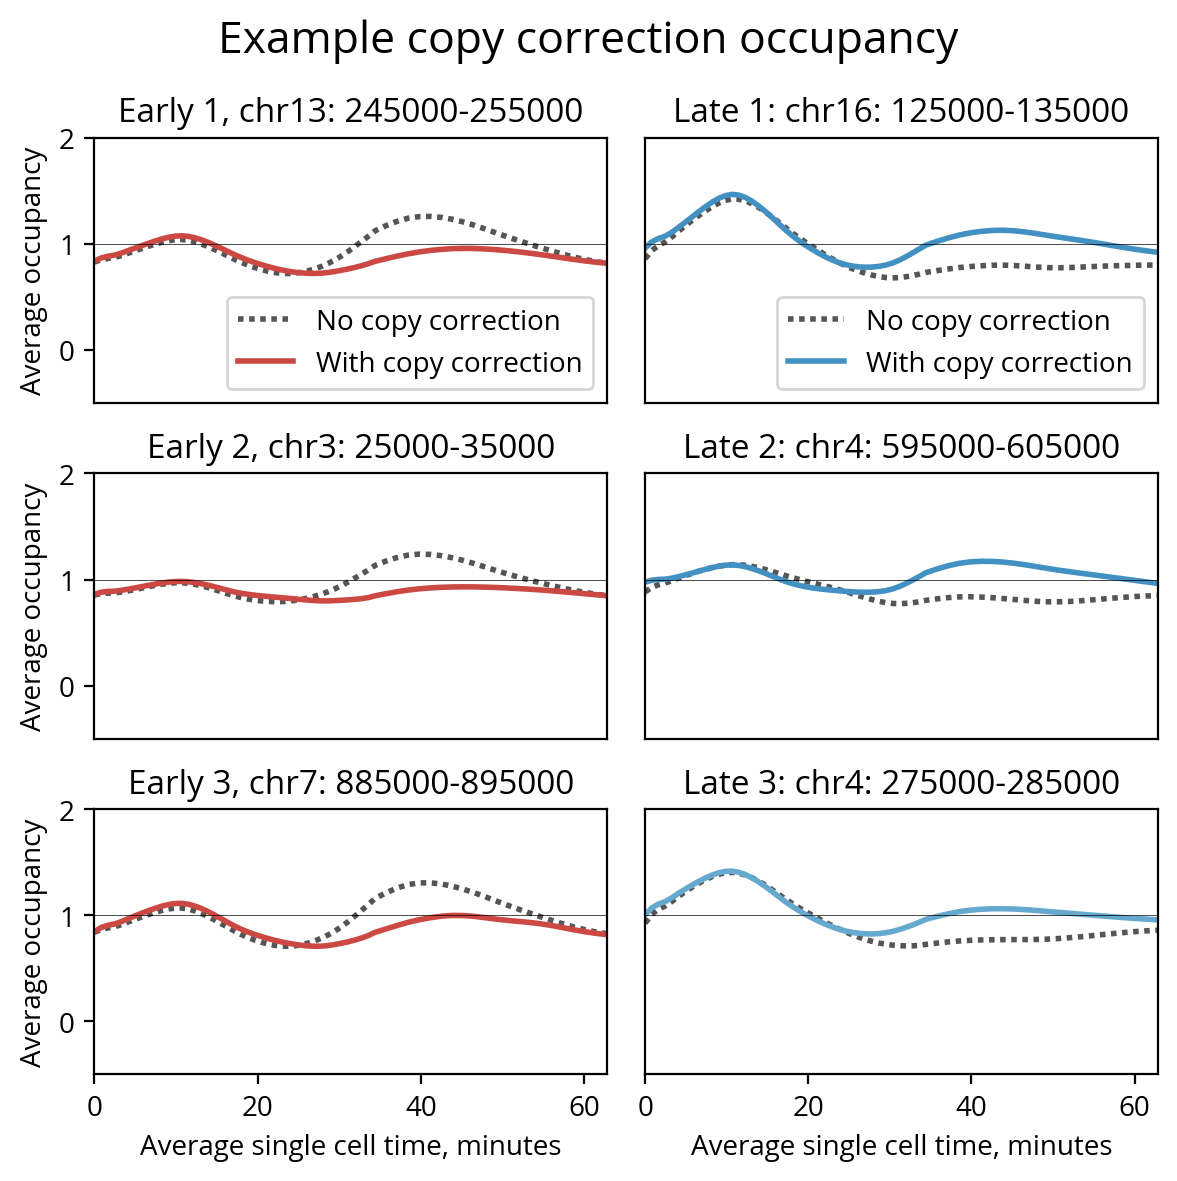

In [524]:
copy_correction_analysis.plot_sample_curves()

# Copy correction, gene-level analysis of chromatin

In [920]:
from pipeline.chromatin_copy_number_analysis import ChromatinCopyNumberAnalysis

# Initialize and run the analysis
analysis = ChromatinCopyNumberAnalysis('output/prototype_pipeline_subset/')
analysis.initialize_analyses()
analysis.load_data()


Initializing ChromatinCopyNumberAnalysis...
Initializing chromatin analysis... copy correction: True
Loading configs from replication runs:  output/prototype_pipeline_subset//single_replication/
Shifting mu0, gamma1, and gamma2, for alpha...
Creating directory: output/prototype_pipeline_subset//chromatin_analysis/...Directory exists. Skipping.
Loading data directory: output/prototype_pipeline_subset//chromatin_deconvolution/deconvolution_data
Copy correction: True
Will save chromatin measures to: output/prototype_pipeline_subset//chromatin_analysis/Loading precomputed chromatin measures
Initializing expression analysis...
Initializing genome deconvolution analysis...
All analyses initialized successfully
Initializing chromatin analysis... copy correction: False
Loading configs from replication runs:  output/prototype_pipeline_subset//single_replication/
Shifting mu0, gamma1, and gamma2, for alpha...
Creating directory: output/prototype_pipeline_subset//chromatin_analysis_no_copy/...Dir

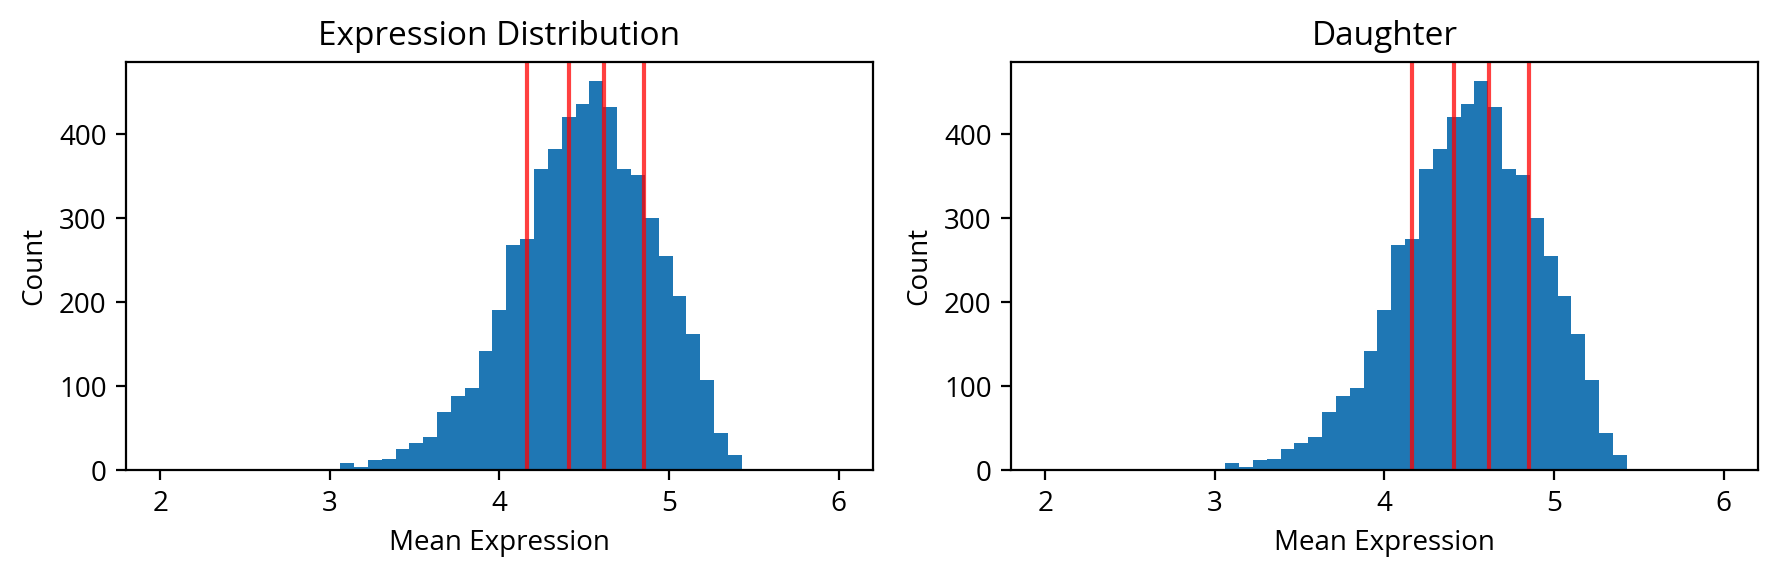

In [949]:
fig = analysis.plot_expression_distribution()

In [921]:
analysis.initialize_replication_time_colormaps()

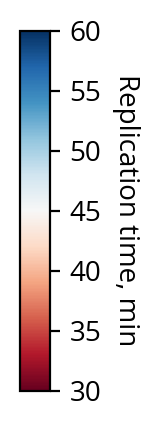

In [969]:
analysis.plot_colorbar()

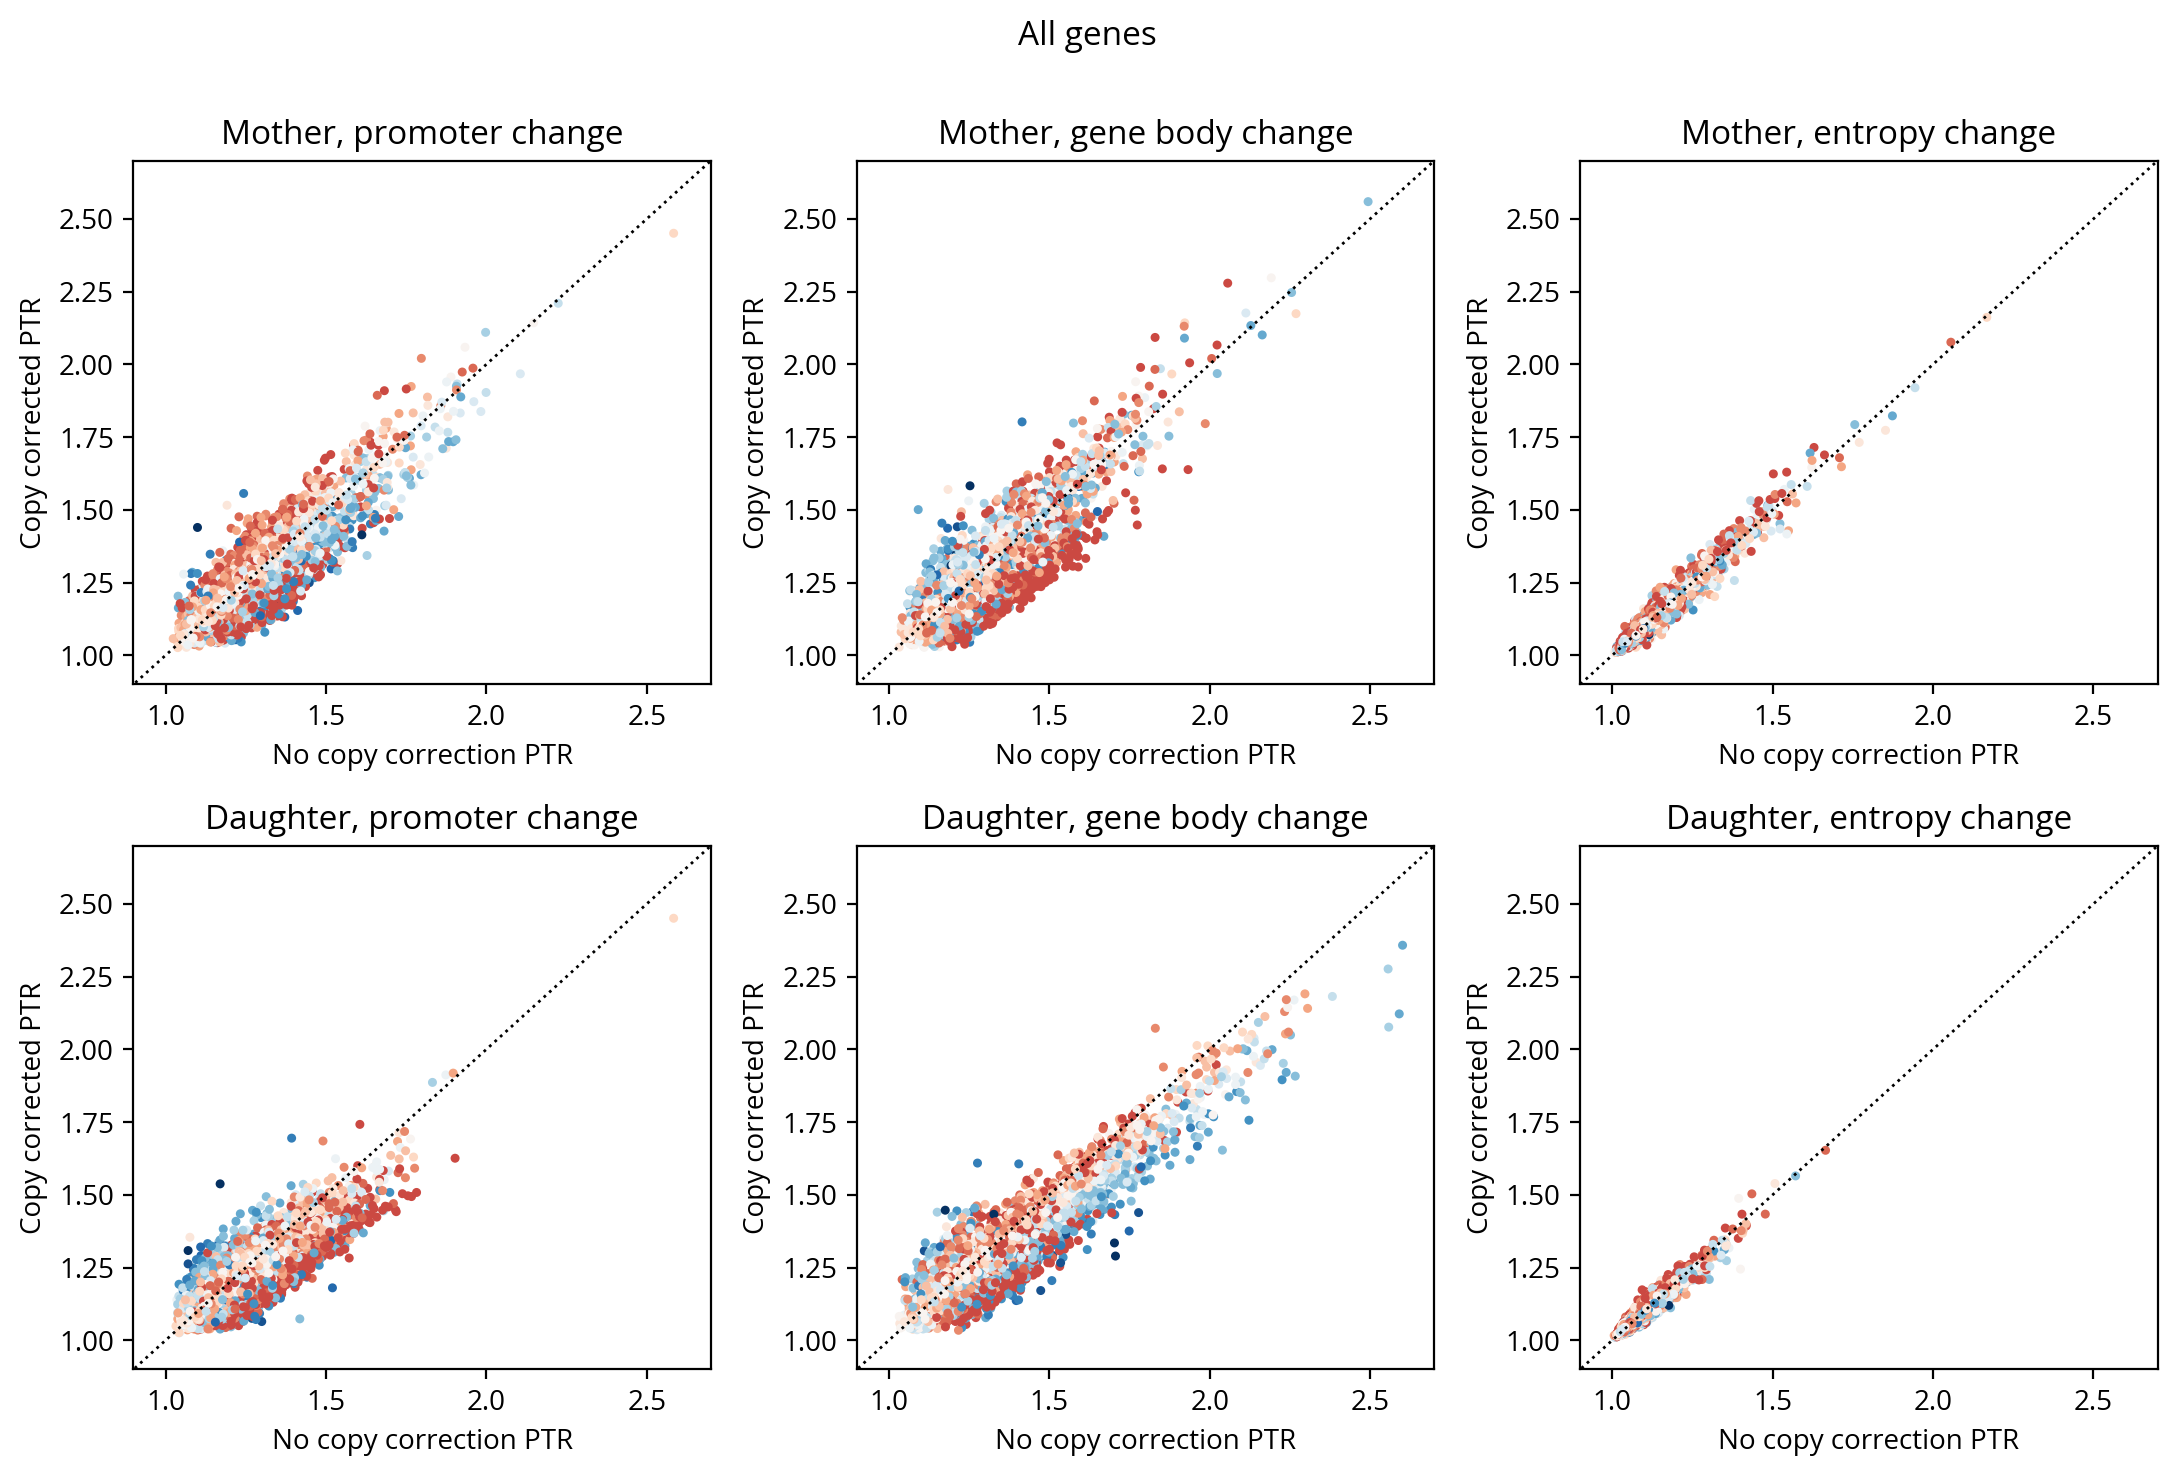

In [950]:
# Create overall comparison plot
fig_all = analysis.create_comparison_figure(title="All genes")

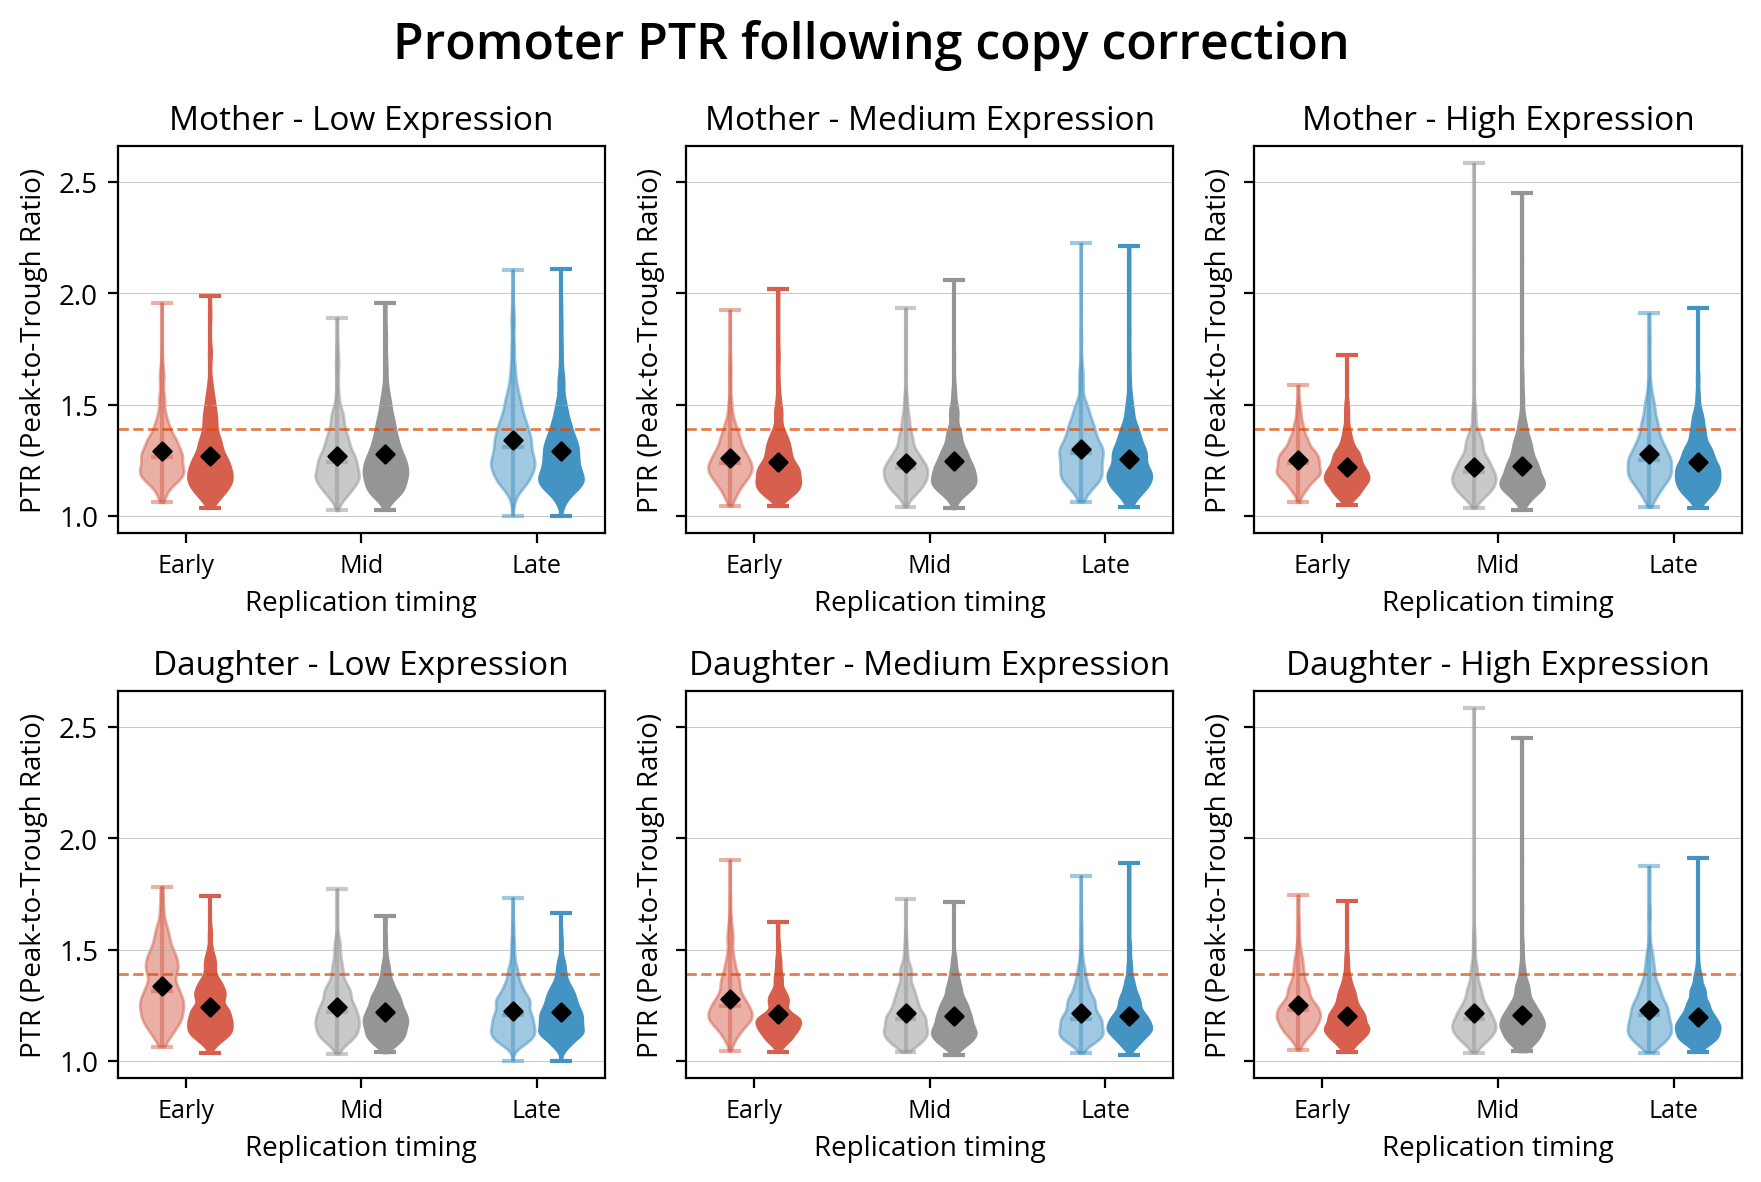

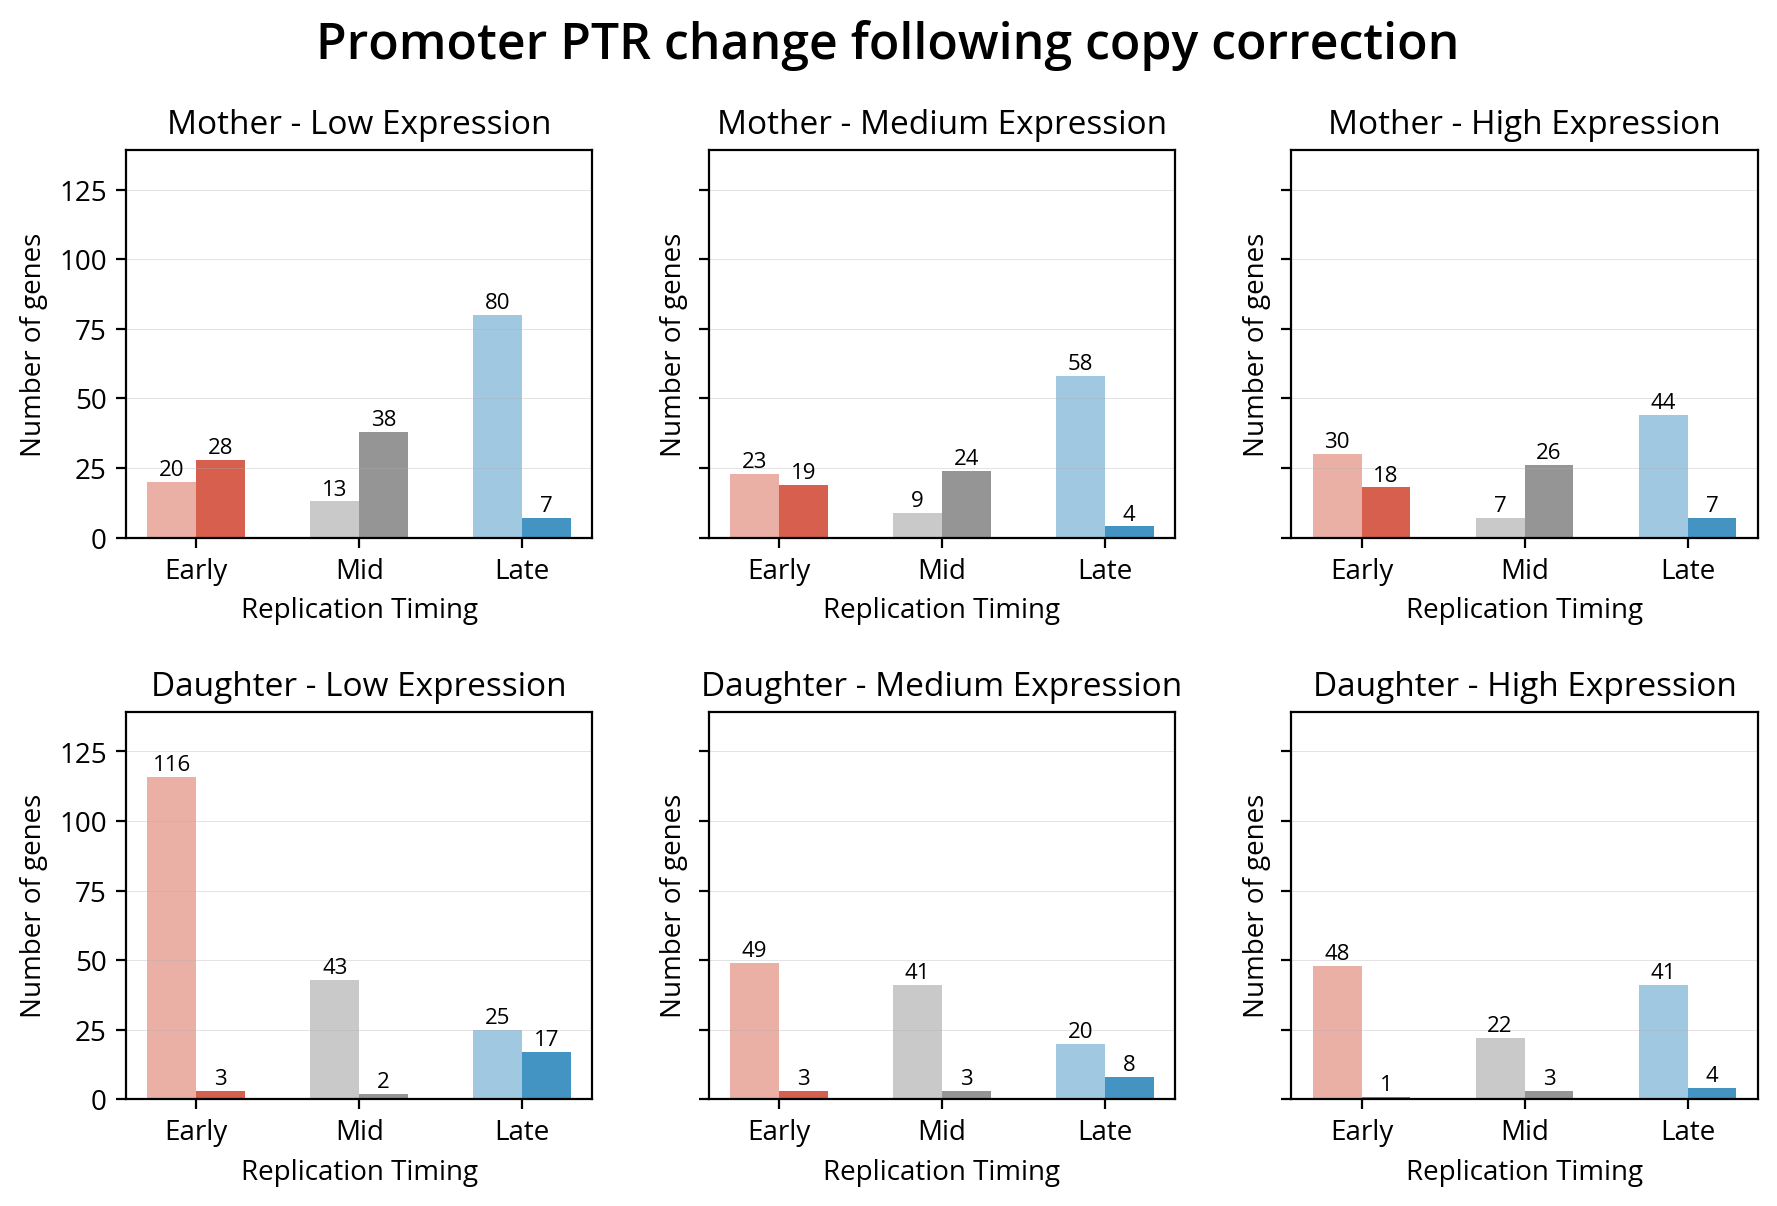

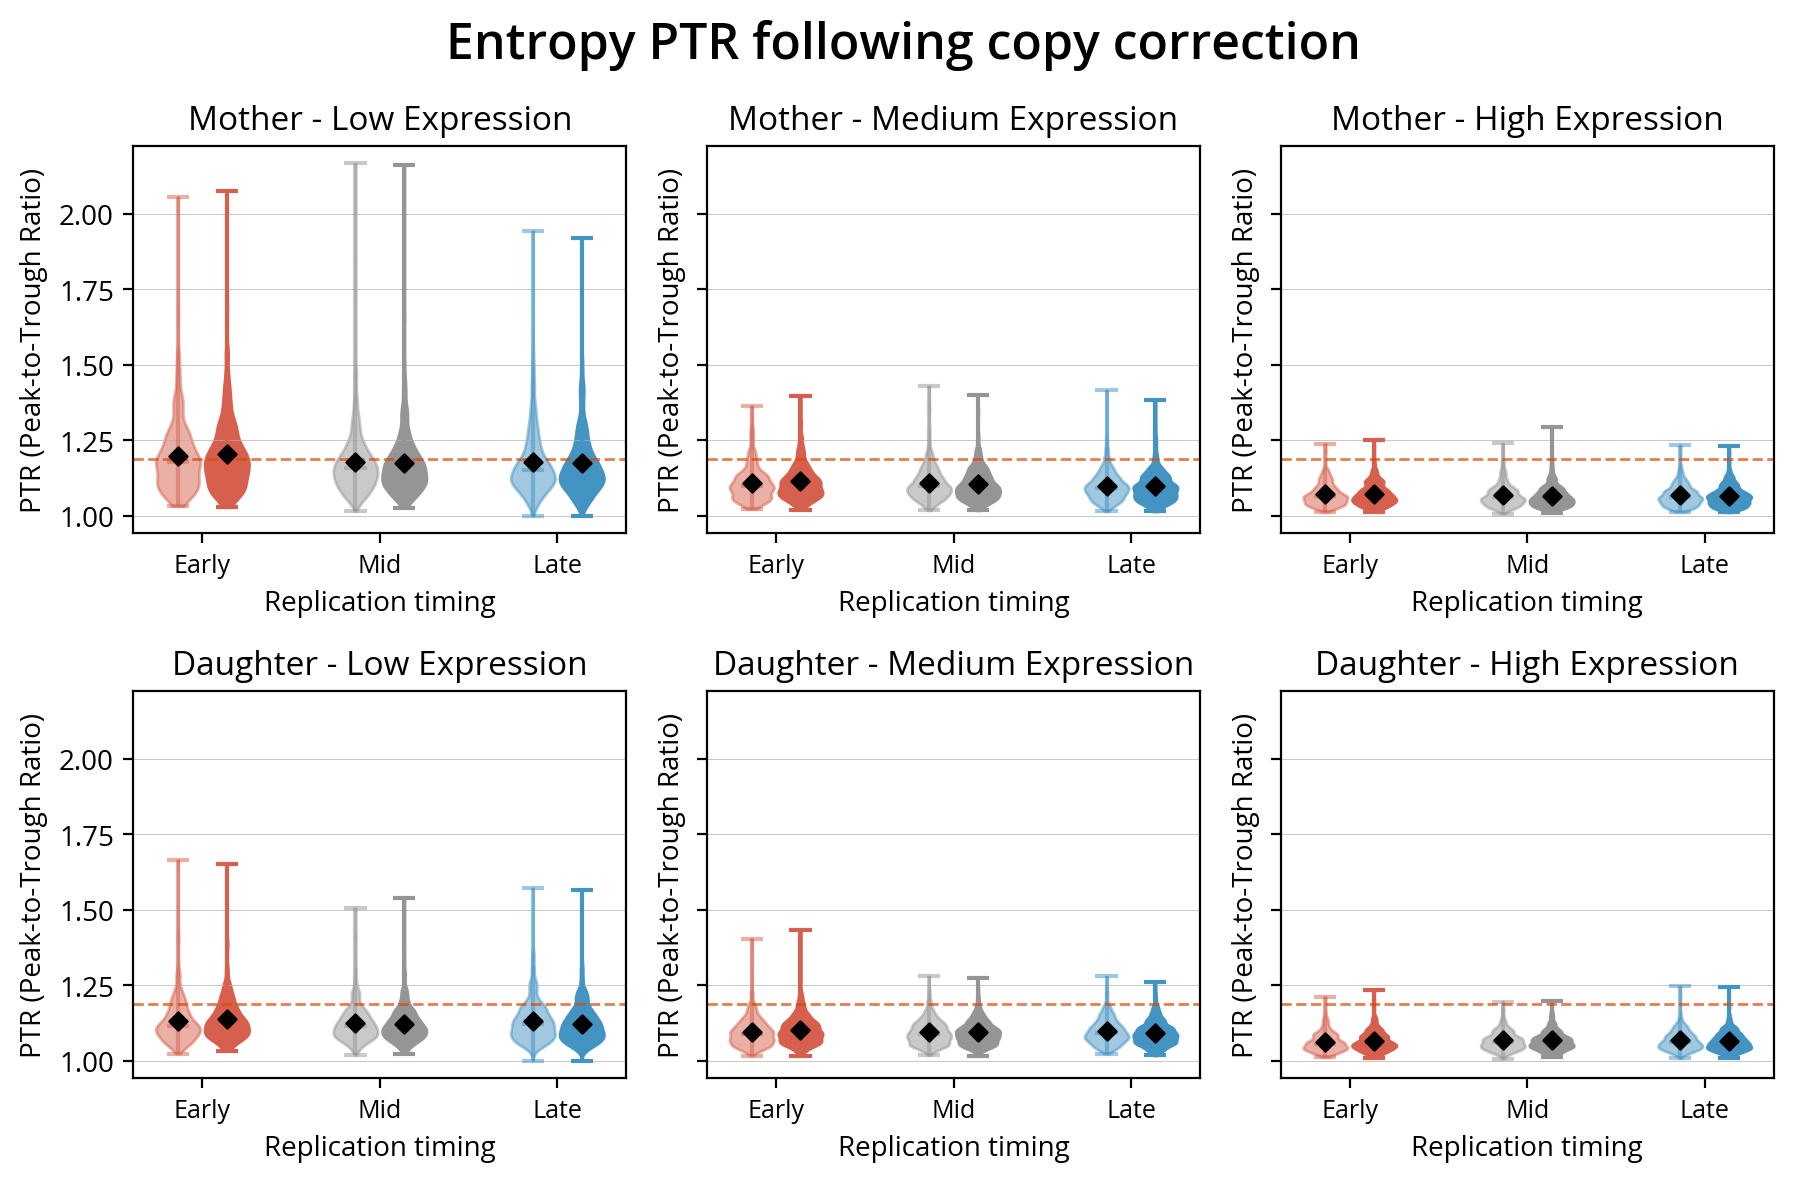

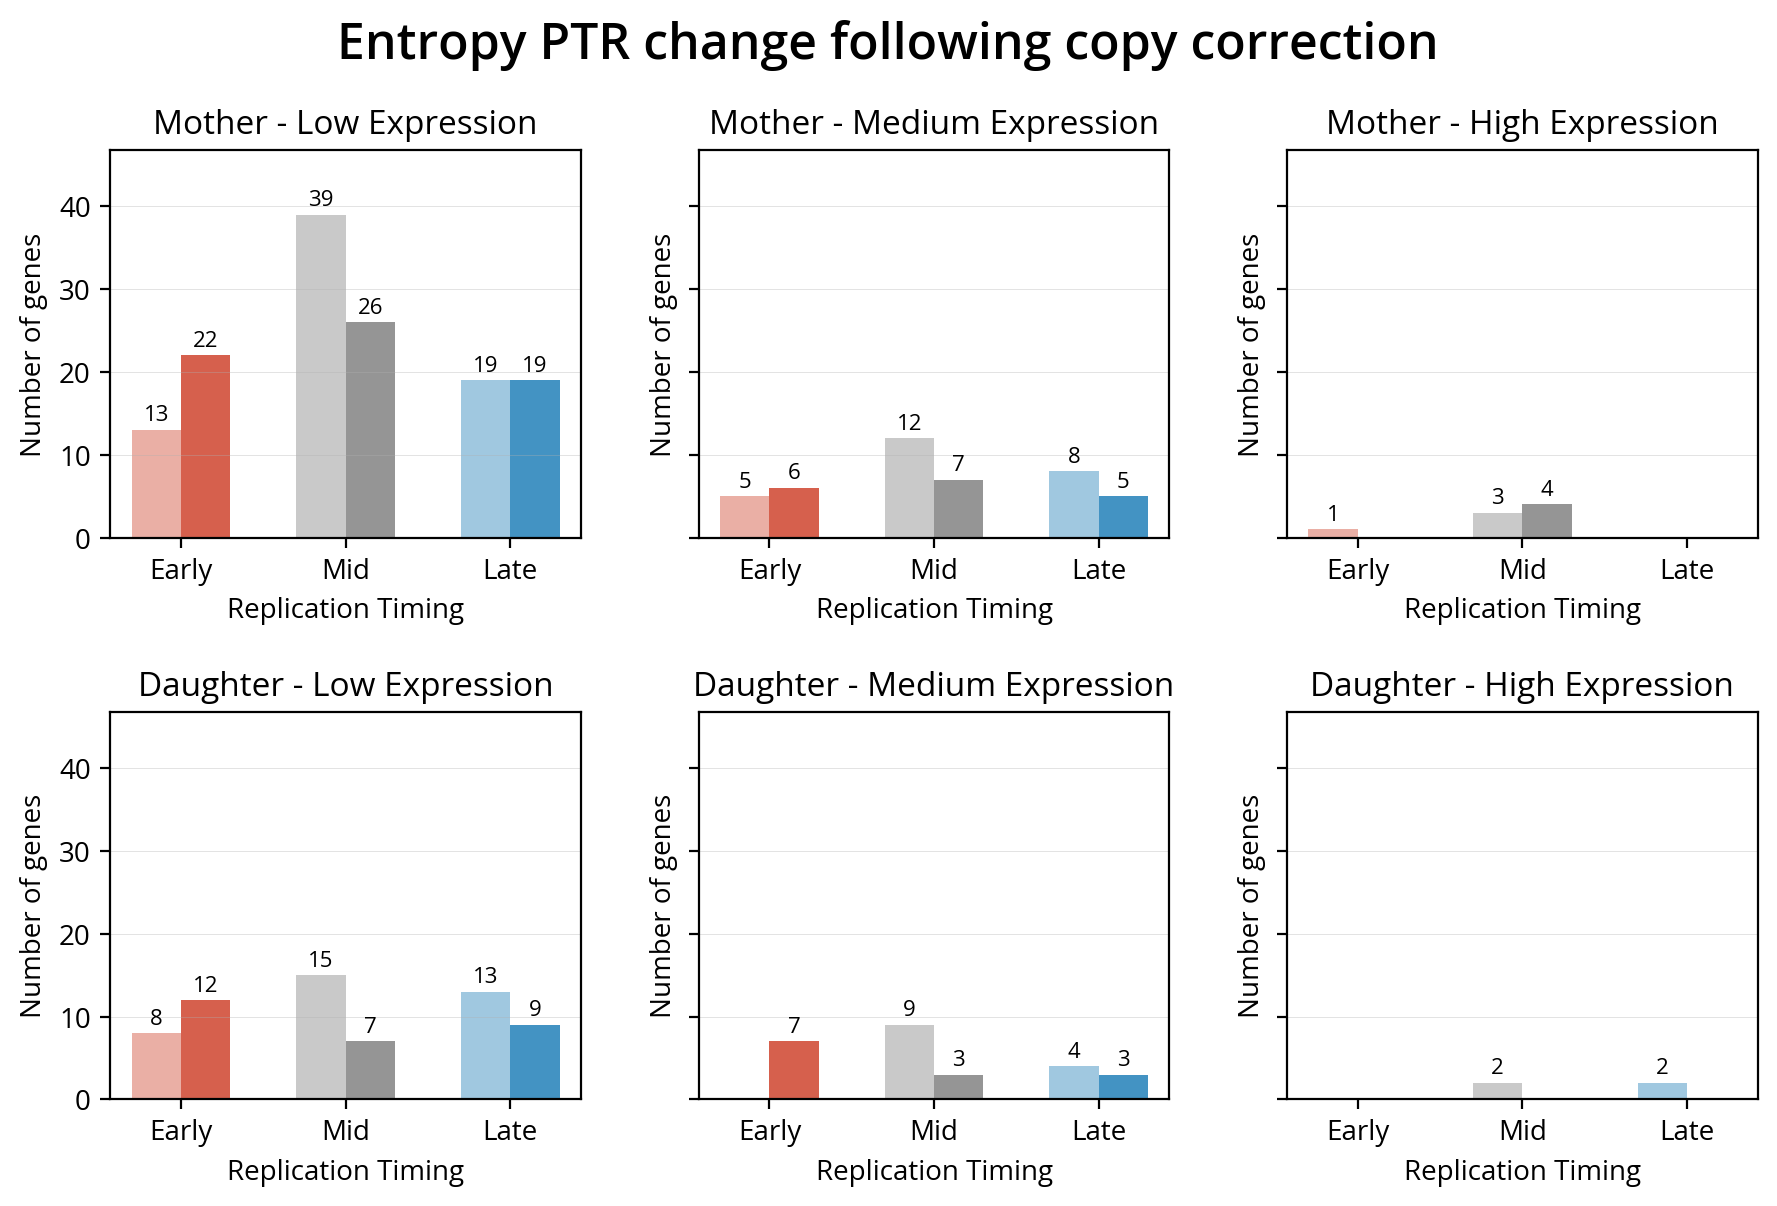

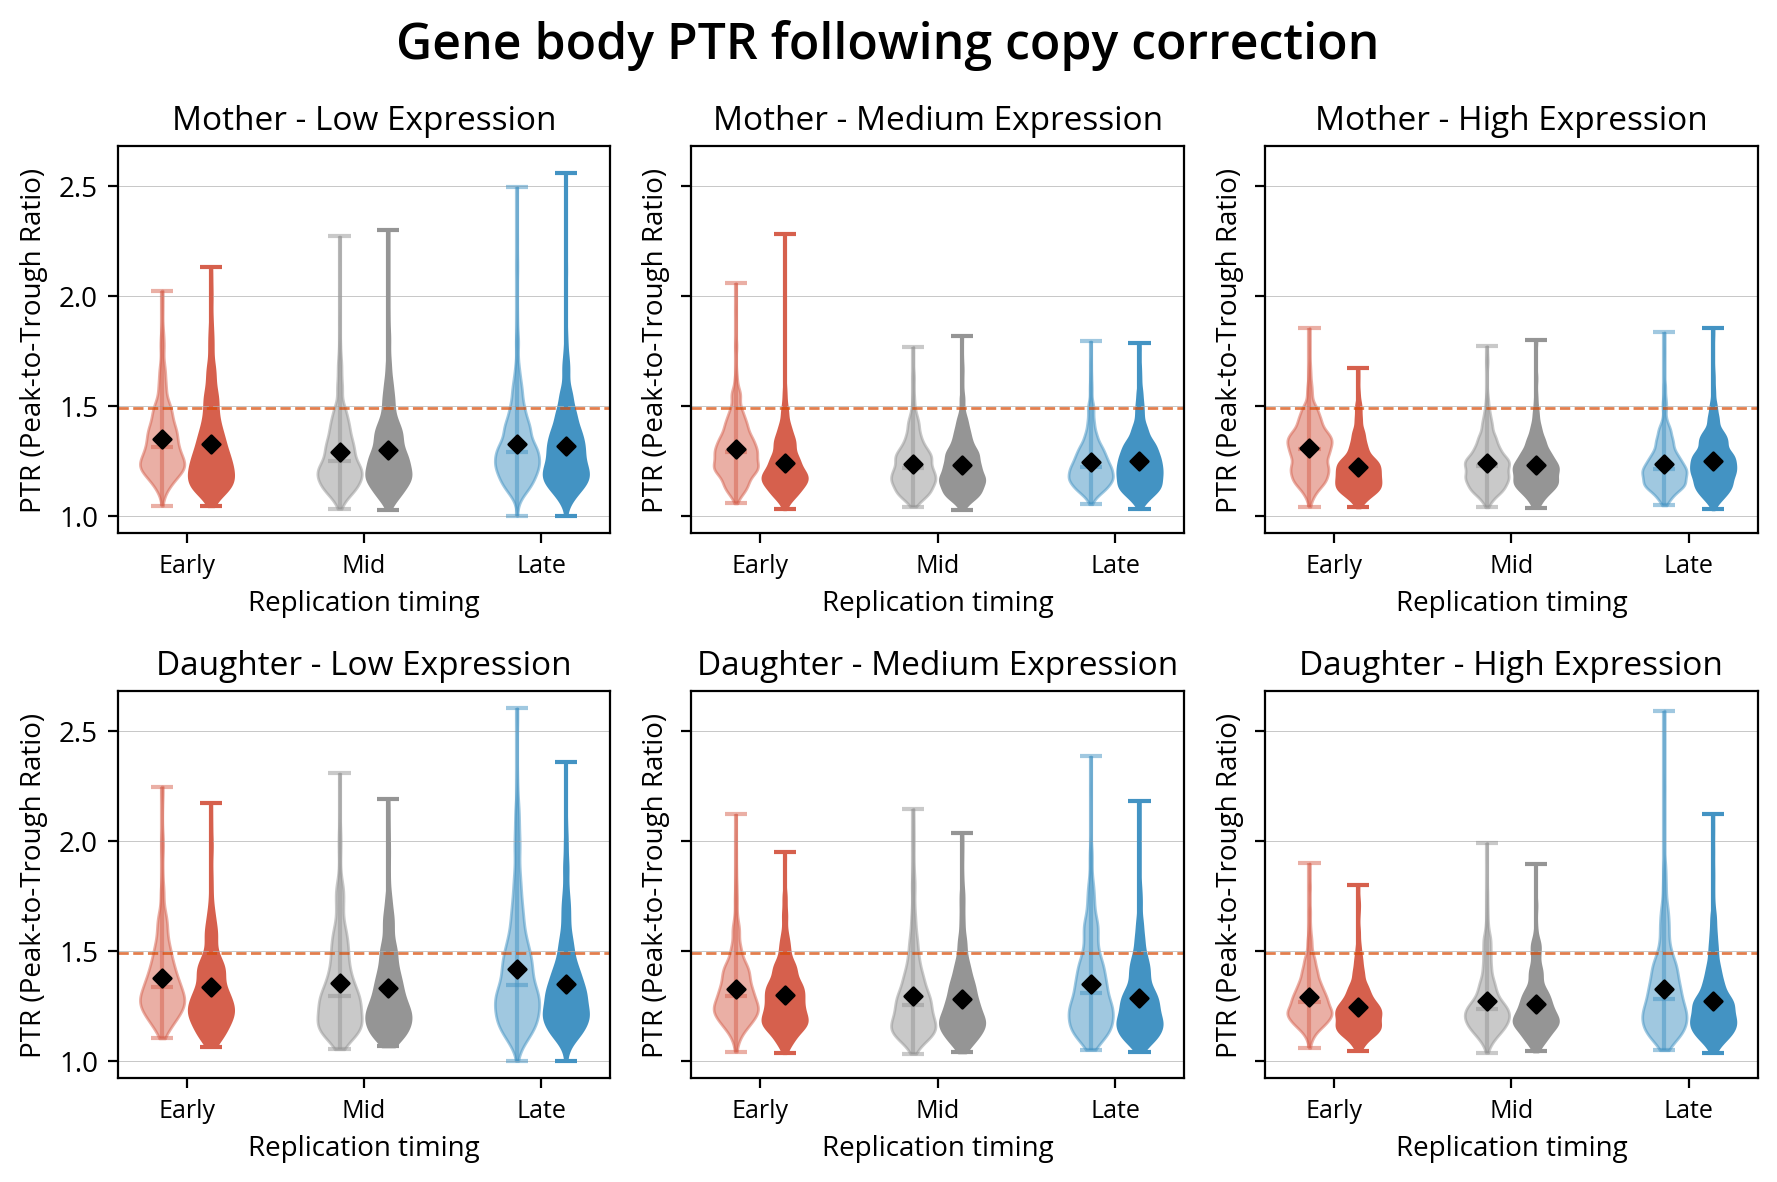

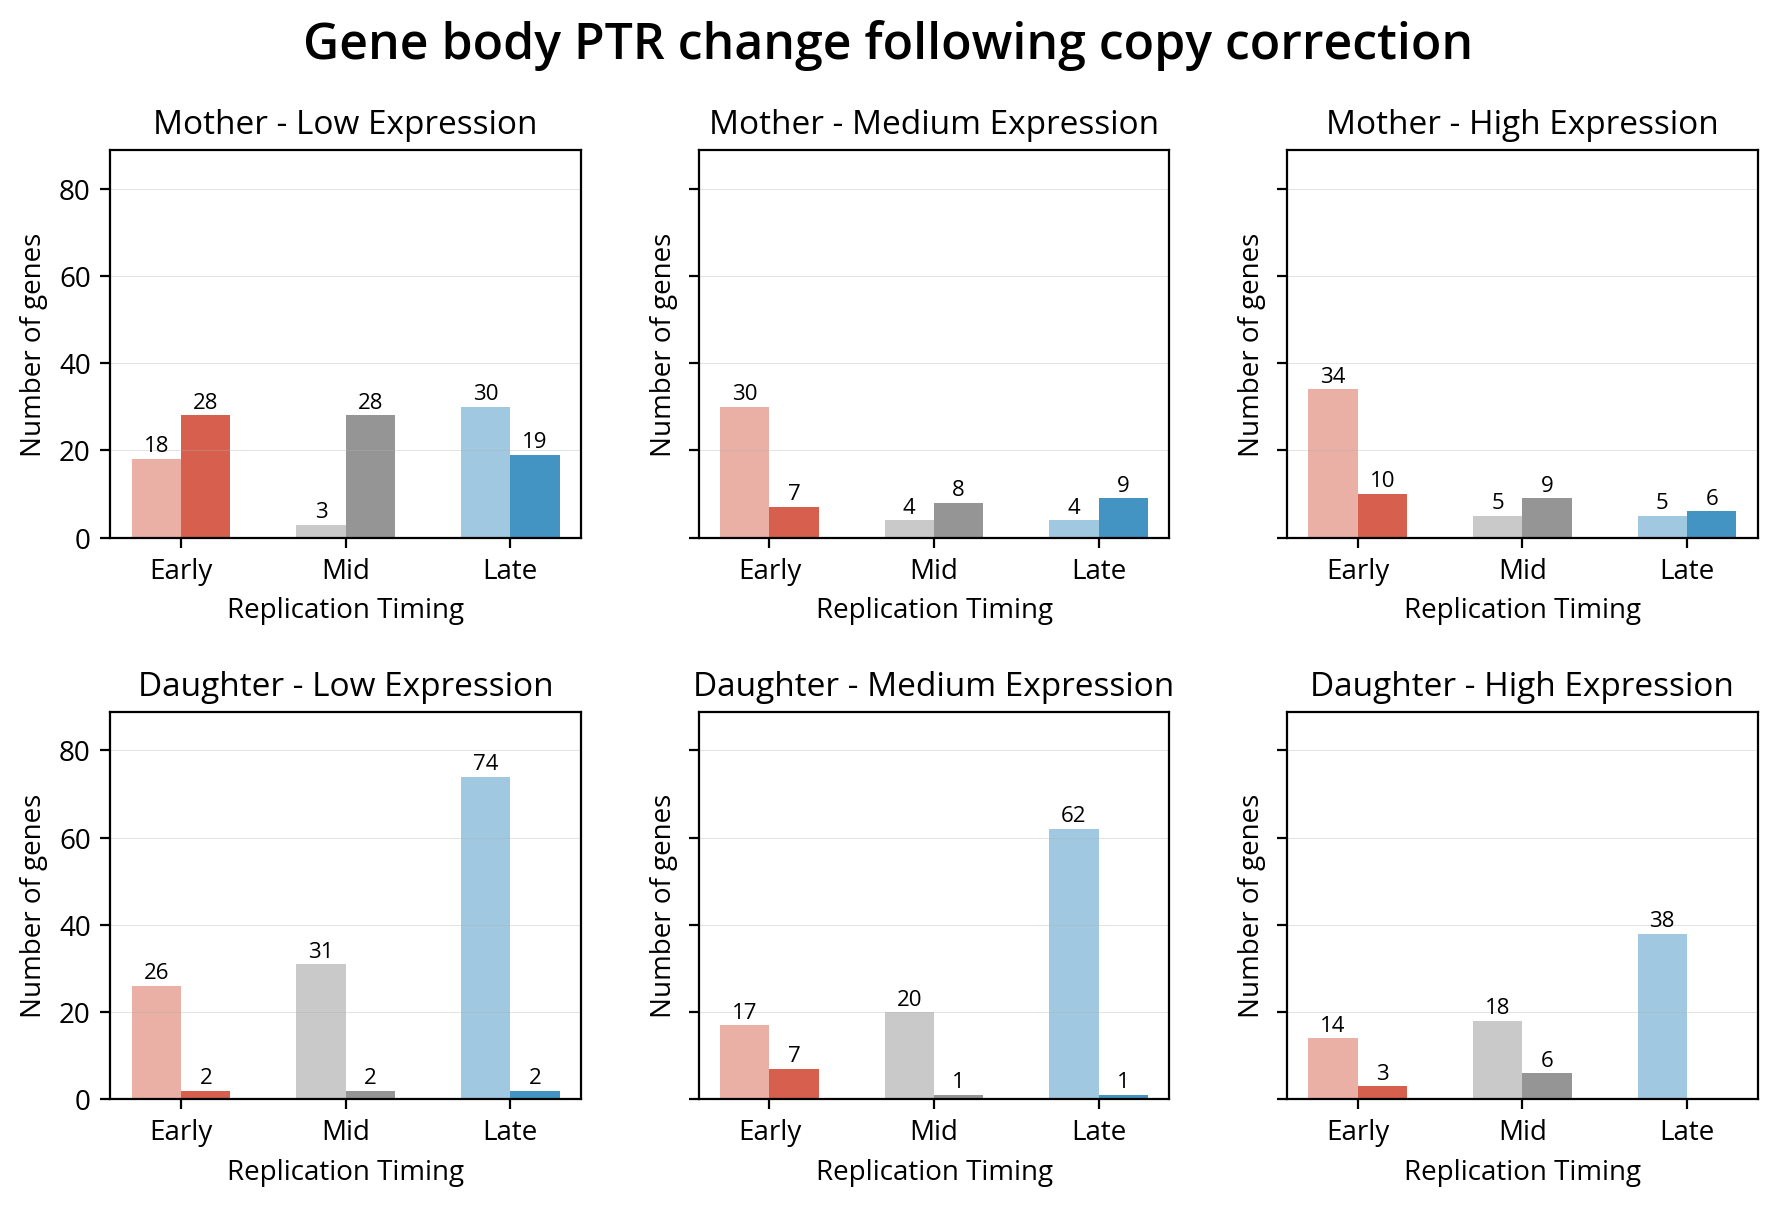

In [1243]:
for metric in ['promoter', 'entropy', 'gene_body']:
    fig, mother_violin_df, daughter_violin_df, cc_thresh\
        = analysis.plot_ptr_violin_plots_by_expression(metric)
    fig, results = analysis.plot_cycling_threshold_changes(metric, mother_violin_df,
        daughter_violin_df, cc_thresh)

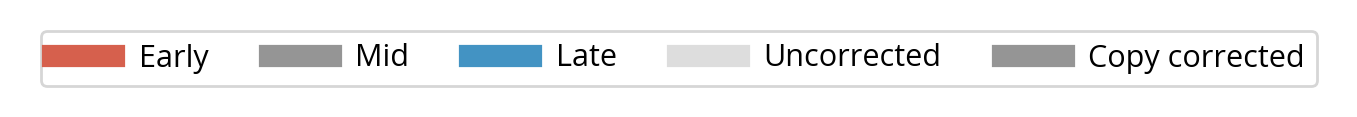

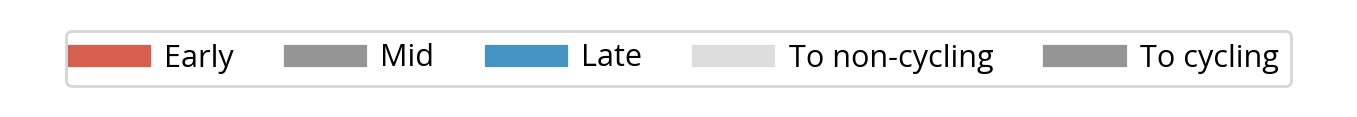

In [1215]:
fig = analysis.create_violin_bar_legend(which='violin')
fig = analysis.create_violin_bar_legend(which='bar')